In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from functools import reduce
import statsmodels.api as sm
from glör_paper_hydra import load_raw
import pickle
import pandas as pd
import shap


In [3]:
ps, in_situ  = load_raw(which_ps="S1")

In [4]:
a = ps.index.values[1:] - ps.index.values[:-1]  
# convert to days
a = a / np.timedelta64(1, 'D')


In [5]:
# periods:
start = in_situ[in_situ["W"] == 284.04].index.min()
end = "2019-01-14"
refill_with_full_data_start = "2019-09-09"
fill_end = "2021-02-08"

drain = ps[(ps.index > start) & (ps.index < end)]
refill = ps[(ps.index > refill_with_full_data_start) & (ps.index < fill_end)]
full = ps[(ps.index > fill_end)]

In [6]:
drain.mean(), refill.mean(), full.mean()

(deform    0.398242
 dtype: float64,
 deform    0.625254
 dtype: float64,
 deform   -0.719941
 dtype: float64)

In [7]:
res = {}


for ps in ["t+s"]:
    m1 = pickle.load(open("results/" + ps + "/drain.p", "rb"))
    m2 = pickle.load(open("results/" + ps + "/refill_T.p", "rb"))
    m3 = pickle.load(open("results/" + ps + "/full_T.p", "rb"))
    m4 = pickle.load(open("results/" + ps + "/refill_W.p", "rb"))
    m5 = pickle.load(open("results/" + ps + "/full_W.p", "rb"))
    m6 = pickle.load(open("results/" + ps + "/refill.p", "rb"))
    m7 = pickle.load(open("results/" + ps + "/full.p", "rb"))
    m8 = pickle.load(open("results/" + ps + "/refill_inter.p", "rb"))
    m9 = pickle.load(open("results/" + ps + "/full_inter.p", "rb"))
    res[ps] = [m1, m2, m3, m4, m5, m6, m7, m8, m9]

In [8]:
import matplotlib.pyplot as plt
import numpy as np

def plot_shap_summary_bar(shap_values, feature_names, max_display=20, title="Feature Importance based on SHAP Values", new=False):
    """
    Creates a nicely formatted horizontal bar plot of SHAP values,
    ordered by their absolute magnitude.

    Parameters:
    - shap_values (np.array or list): The SHAP values for each feature.
    - feature_names (list of str): The names of the features, corresponding to shap_values.
    - max_display (int): Maximum number of features to display.
    - title (str): The title of the plot.
    """
    if len(shap_values) != len(feature_names):
        raise ValueError("Length of shap_values and feature_names must be the same.")

    # Convert to numpy arrays if they aren't already
    shap_values = np.array(shap_values)
    feature_names = np.array(feature_names)

    # 1. Get absolute SHAP values to determine importance
    abs_shap_values = np.abs(shap_values)

    # 2. Get the indices that would sort by absolute SHAP values (ascending)
    sorted_indices = np.argsort(abs_shap_values)

    # 3. Select top `max_display` features (or all if fewer)
    # These will be the ones with the largest absolute SHAP values
    # If sorted_indices is [idx_smallest_abs, ..., idx_largest_abs],
    # then sorted_indices[-max_display:] gives the indices of the top features.
    if len(sorted_indices) > max_display:
        top_indices = sorted_indices[-max_display:]
    else:
        top_indices = sorted_indices

    # 4. Get the corresponding SHAP values and feature names for the top features
    # These are still sorted by absolute value in ascending order
    top_shap_values = shap_values[top_indices]
    top_feature_names = feature_names[top_indices]

    # 5. Create colors based on the sign of the SHAP value
    colors = ['#b0c4a4' if not new else "#f0dfa2" for s in top_shap_values] # Red for negative, Blue for positive

    # 6. Create the plot
    plt.figure(figsize=(7, len(top_feature_names) * 0.4 + 1.5)) # Adjust height dynamically
    
    # Plot bars
    bars = plt.barh(range(len(top_shap_values)), top_shap_values, color=colors, align='center')

    # Add y-axis ticks and labels (feature names)
    plt.yticks(range(len(top_shap_values)), top_feature_names , fontsize=20)

    # Add labels and title
    plt.xlabel("Mean Absolute SHAP Value (Impact on Model Output)", fontsize=15)
    plt.ylabel("Feature", fontsize=18)
    plt.title(title, fontsize=18)

    # Add a vertical line at x=0 for reference
    plt.axvline(0, color='grey', linestyle='--', linewidth=0.8)

    # Add value labels on bars (optional, can be crowded for many bars)
    for bar in bars:
        width = bar.get_width()
        label_x_pos = width + (max(top_shap_values) * 0.01) if width >= 0 else width - (abs(min(top_shap_values)) * 0.01) # Small offset
        
        # Adjust alignment based on sign
        ha = 'left' if width >= 0 else 'right'
        
        plt.text(label_x_pos, 
                 bar.get_y() + bar.get_height()/2, 
                 f'{width:.3f}', 
                 va='center', 
                 ha=ha,
                 fontsize=18)


    # Improve layout
    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)
    plt.grid(axis='x', linestyle=':', alpha=0.7)
    plt.tight_layout() # Adjust plot to ensure everything fits without overlapping


In [9]:
def to_subscript(s):
    sub_map = str.maketrans("0123456789t", "₀₁₂₃₄₅₆₇₈₉ₜ")
    return ''.join([c.translate(sub_map) if c in "0123456789t" else c for c in s])

[subscripted := [to_subscript(f) for f in ["Tt","Tt1","Wt","Wt1", "Tt*Wt", "Tt1*Wt1", "Tt-Tt1", "Wt-Wt1","Trt"]]]


[['Tₜ', 'Tₜ₁', 'Wₜ', 'Wₜ₁', 'Tₜ*Wₜ', 'Tₜ₁*Wₜ₁', 'Tₜ-Tₜ₁', 'Wₜ-Wₜ₁', 'Trₜ']]

['T_0', 'T_1', 'W_0', 'W_1', 'inter_0', 'inter_1', 'W_diff', 'T_diff', 'const', 'trend']
['Tₜ', 'Tₜ₁', 'Wₜ', 'Wₜ₁', 'Tₜ*Wₜ', 'Tₜ₁*Wₜ₁', 'Wₜ-Wₜ₁', 'Tₜ-Tₜ₁', 'Con', 'Trₜ', 'Const']
['T_0', 'T_1', 'W_0', 'W_1', 'inter_0', 'inter_1', 'W_diff', 'T_diff', 'const', 'trend']


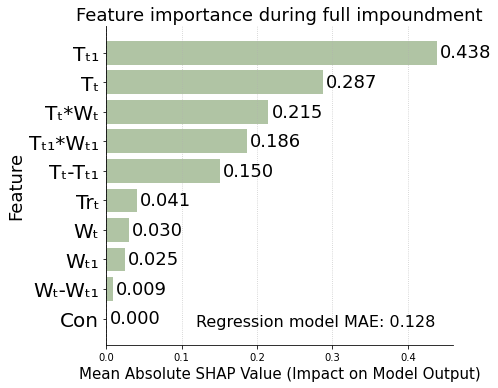

In [11]:
# a classic housing price dataset
X = pd.read_csv("data_saves/temporaryfull_inter.csv", index_col=0)
X10 = shap.utils.sample(X, 100)  # 100 instance
# compute the SHAP values for the linear model
explainer = shap.Explainer(m9.predict, X10)
shap_values = explainer(X)
[subscripted := [to_subscript(f) for f in ["Tt","Tt1","Wt","Wt1", "Tt*Wt", "Tt1*Wt1", "Wt-Wt1","Tt-Tt1","Con", "Trt"]]]
print(shap_values.feature_names)
print(subscripted + ["Const"])
plot_shap_summary_bar(shap_values.abs.mean(0).values,subscripted , title="Feature importance during full impoundment")
plt.text(
    0.95, 0.05, "Regression model MAE: 0.128",
    fontsize=16, color="black", ha="right", va="bottom",
    transform=plt.gca().transAxes
)
print(shap_values.feature_names)
plt.savefig("imgs/shap_waterfall_full_inter.pdf", bbox_inches="tight")

['T_0', 'T_1', 'W_0', 'W_1', 'inter_0', 'inter_1', 'W_diff', 'T_diff', 'const', 'trend']
['Tₜ', 'Tₜ₁', 'Wₜ', 'Wₜ₁', 'Tₜ*Wₜ', 'Tₜ₁*Wₜ₁', 'Wₜ-Wₜ₁', 'Tₜ-Tₜ₁', 'Con', 'Trₜ', 'Const']
['T_0', 'T_1', 'W_0', 'W_1', 'inter_0', 'inter_1', 'W_diff', 'T_diff', 'const', 'trend']


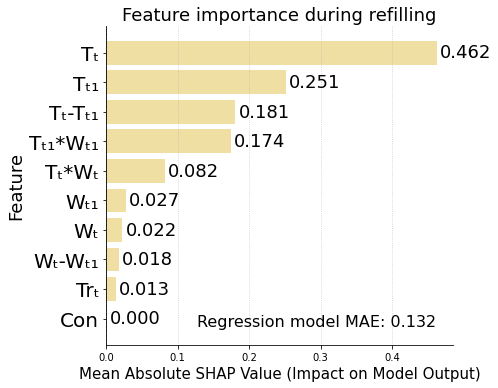

In [13]:
# a classic housing price dataset
X = pd.read_csv("data_saves/temporaryrefill_inter.csv", index_col=0)
X10 = shap.utils.sample(X, 100)  # 100 instance
# compute the SHAP values for the linear model
explainer = shap.Explainer(m8.predict, X10)
shap_values = explainer(X)
[subscripted := [to_subscript(f) for f in ["Tt","Tt1","Wt","Wt1", "Tt*Wt", "Tt1*Wt1","Wt-Wt1","Tt-Tt1","Con", "Trt"]]]
print(shap_values.feature_names)
print(subscripted + ["Const"])
plot_shap_summary_bar(shap_values.abs.mean(0).values,subscripted, title="Feature importance during refilling", new=True)
print(shap_values.feature_names)
plt.text(
    0.95, 0.05, "Regression model MAE: 0.132",
    fontsize=16, color="black", ha="right", va="bottom",
    transform=plt.gca().transAxes
)
plt.savefig("imgs/shap_waterfall_refill_inter.pdf", bbox_inches="tight")

### Nr2: Residual comparison


In [14]:
import pandas as pd

data = {
    "Full(t+s)": [
        res["t+s"][8].resid.abs().mean(),
        #res["t+s"][6].resid.abs().mean(),
        #res["t+s"][4].resid.abs().mean(),
        #res["t+s"][2].resid.abs().mean()
    ],
    # "Full (S1)": [
    #     res["S1"][8].resid.abs().mean(),
    #     res["S1"][6].resid.abs().mean(),
    #     res["S1"][4].resid.abs().mean(),
    #     res["S1"][2].resid.abs().mean()
    # ],
    # "Full (tsx)": [
    #     res["tsx"][8].resid.abs().mean(),
    #     res["tsx"][6].resid.abs().mean(),
    #     res["tsx"][4].resid.abs().mean(),
    #     res["tsx"][2].resid.abs().mean()
    # ],
    "Filling(t+s)": [
        res["t+s"][7].resid.abs().mean(),
        #res["t+s"][5].resid.abs().mean(),
        #res["t+s"][3].resid.abs().mean(),
        #res["t+s"][1].resid.abs().mean()
    ],
    # "Filling(S1)": [
    #     res["S1"][7].resid.abs().mean(),
    #     res["S1"][5].resid.abs().mean(),
    #     res["S1"][3].resid.abs().mean(),
    #     res["S1"][1].resid.abs().mean()
    # ],
    # "Filling(tsx)": [
    #     res["tsx"][7].resid.abs().mean(),
    #     res["tsx"][5].resid.abs().mean(),
    #     res["tsx"][3].resid.abs().mean(),
    #     res["tsx"][1].resid.abs().mean()
    # ],
    "Empty (t+s)": [
        res["t+s"][0].resid.abs().mean()
     ],
    # "Empty (S1)": [
    #     None, None, None,res["S1"][0].resid.abs().mean()
    # ],
    # "Empty (tsx)": [
    #     None, None, None,res["tsx"][0].resid.abs().mean()
    # ],


}

df_resid = pd.DataFrame(data, index=["W*T"])
df_resid.index.name = "Full"
df_resid = df_resid.round(3)

df_resid = df_resid.T.astype(str)

df_resid = df_resid.replace("nan", "-")

In [16]:
print(df_resid.to_latex())

\begin{tabular}{ll}
\toprule
Full &    W*T \\
\midrule
Full(t+s)    &  0.128 \\
Filling(t+s) &  0.132 \\
Empty (t+s)  &  0.136 \\
\bottomrule
\end{tabular}



/tmp/ipykernel_3148092/1241366999.py:1: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  print(df_resid.to_latex())


In [17]:
res["t+s"][7].rsquared, res["t+s"][8].rsquared

(0.4949353910914588, 0.3936391620286981)

### Nr1: Model comparison: 

In [18]:
print(res["t+s"][0].summary().tables[1])

                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
T_0            0.4913      0.080      6.154      0.000       0.332       0.651
const          0.1463      0.051      2.880      0.005       0.045       0.248
trend          0.3096      0.080      3.855      0.000       0.149       0.470


In [19]:
print(res["t+s"][7].summary().tables[1])

                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
T_0            2.3964      1.402      1.709      0.092      -0.397       5.190
T_1           -1.2833      1.344     -0.955      0.343      -3.960       1.393
W_0            0.2164      0.102      2.119      0.037       0.013       0.420
W_1            0.2599      0.111      2.338      0.022       0.038       0.481
inter_0        0.4885      0.224      2.178      0.033       0.042       0.935
inter_1       -0.9899      0.257     -3.854      0.000      -1.501      -0.478
W_diff         0.2001      0.145      1.381      0.171      -0.088       0.489
T_diff         1.3412      0.735      1.825      0.072      -0.123       2.805
const         -0.7560      0.415     -1.820      0.073      -1.583       0.071
trend          0.0528      0.086      0.616      0.540      -0.118       0.223


In [21]:
print(res["t+s"][8].summary().tables[1])

                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
T_0           -1.4220      4.104     -0.346      0.730      -9.586       6.742
T_1            2.1804      4.166      0.523      0.602      -6.108      10.468
W_0            0.1958      0.112      1.746      0.084      -0.027       0.419
W_1            0.1544      0.121      1.281      0.204      -0.085       0.394
inter_0       -1.6817      1.261     -1.334      0.186      -4.190       0.826
inter_1        1.4714      1.326      1.110      0.270      -1.166       4.109
W_diff        -0.1093      0.161     -0.678      0.500      -0.430       0.211
T_diff        -1.2206      1.714     -0.712      0.478      -4.630       2.189
const          0.4229      0.590      0.717      0.476      -0.751       1.597
trend          0.1624      0.077      2.118      0.037       0.010       0.315


In [23]:
res["t+s"][7].rsquared, res["t+s"][8].rsquared

(0.4949353910914588, 0.3936391620286981)